# Video Game Industry Analysis (2000–2013) Based on Sales and Ratings Data

## Project Overview

This project analyzes the development of the video game industry from 2000 to 2013 based on sales, platforms, and user and critic ratings.

The goal is to identify key trends and factors influencing game success.

## Data Loading and Initial Exploration

We load the necessary libraries and import the dataset.

Then, we perform an initial exploration of the data by examining its structure and displaying the first rows of the DataFrame.

In [657]:
# Import the pandas library
import pandas as pd

In [658]:
# Import Matplotlib for visualization
import matplotlib.pyplot as plt

In [659]:
# Load data from the dataset new_games.csv into a DataFrame
games_raw = pd.read_csv('../data/new_games.csv')

In [660]:
# Create working copy
games = games_raw.copy()

In [661]:
# Display information about the DataFrame
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16956 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16954 non-null  object 
 1   Platform         16956 non-null  object 
 2   Year of Release  16681 non-null  float64
 3   Genre            16954 non-null  object 
 4   NA sales         16956 non-null  float64
 5   EU sales         16956 non-null  object 
 6   JP sales         16956 non-null  object 
 7   Other sales      16956 non-null  float64
 8   Critic Score     8242 non-null   float64
 9   User Score       10152 non-null  object 
 10  Rating           10085 non-null  object 
dtypes: float64(4), object(7)
memory usage: 1.4+ MB


In [662]:
# Display the first rows of the DataFrame
games.head()

,Name,Platform,Year of Release,Genre,NA sales,EU sales,JP sales,Other sales,Critic Score,User Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [663]:
# Display the last rows of the DataFrame
games.tail()

,Name,Platform,Year of Release,Genre,NA sales,EU sales,JP sales,Other sales,Critic Score,User Score,Rating
16951,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.0,0.01,0.0,NaN,NaN,NaN
16952,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.0,0.0,NaN,NaN,NaN
16953,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.0,0.01,0.0,NaN,NaN,NaN
16954,Spirits & Spells,GBA,2003.0,Platform,0.01,0.0,0.0,0.0,NaN,NaN,NaN
16955,Winning Post 8 2016,PSV,2016.0,Simulation,0.00,0.0,0.01,0.0,NaN,NaN,NaN


## Initial Data Overview

**Conclusion**

The dataset contains **16,956 rows and 11 columns**. It includes information about video games, their platforms, genres, release years, regional sales, as well as user and critic ratings.

The column names use spaces and capital letters, which do not follow the snake_case convention and may complicate further analysis. Therefore, they will need to be standardized.

Missing values are present in the dataset:
- the `Name` and `Genre` columns contain a small number of missing values
- the `Year of Release` column has missing entries
- the `Critic Score`, `User Score`, and `Rating` columns contain a significant number of missing values

This may be due to unavailable information at the time of data collection or because some games were not rated.

There are also issues with data types:
- the `EU sales` and `JP sales` columns are of type `object`, although they contain numerical values and require conversion
- the `User Score` column is also stored as `object` despite representing numeric data
- the `Year of Release` column is of type `float64`, likely due to the presence of missing values

Before proceeding with the analysis, it is necessary to:
- convert column names to snake_case
- handle missing values
- correct data types in numerical columns
- check for implicit duplicates in categorical data

## Data Preprocessing

### Column Names

We examine the column names and standardize them to follow the snake_case convention.

In [664]:
# Display column names
games.columns

Index(['Name', 'Platform', 'Year of Release', 'Genre', 'NA sales', 'EU sales',
       'JP sales', 'Other sales', 'Critic Score', 'User Score', 'Rating'],
      dtype='object')

In [665]:
# Convert column names to lowercase and replace spaces with underscores
games.columns = games.columns.str.lower().str.replace(' ', '_')

In [666]:
# Display updated column names
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

**Conclusion**

The original column names contained spaces and uppercase letters, which do not follow best practices for data analysis.

All column names were converted to lowercase and spaces were replaced with underscores. This ensures consistency and simplifies further analysis.

### Data Types

We analyze the data types and convert incorrect types where necessary.

In [667]:
# Display dataset information (data types and missing values)
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16956 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16954 non-null  object 
 1   platform         16956 non-null  object 
 2   year_of_release  16681 non-null  float64
 3   genre            16954 non-null  object 
 4   na_sales         16956 non-null  float64
 5   eu_sales         16956 non-null  object 
 6   jp_sales         16956 non-null  object 
 7   other_sales      16956 non-null  float64
 8   critic_score     8242 non-null   float64
 9   user_score       10152 non-null  object 
 10  rating           10085 non-null  object 
dtypes: float64(4), object(7)
memory usage: 1.4+ MB


Key observations:

- `eu_sales` and `jp_sales` are stored as object but should be numeric
- `user_score` is also object despite representing numeric values
- `year_of_release` is float, likely due to missing values

In [668]:
# Convert sales columns to numeric values
games['eu_sales'] = pd.to_numeric(games['eu_sales'], errors='coerce')
games['jp_sales'] = pd.to_numeric(games['jp_sales'], errors='coerce')

# Convert user score to numeric
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

# Convert year to integer type while preserving missing values
games['year_of_release'] = pd.to_numeric(
    games['year_of_release'], errors='coerce'
).astype('Int64')

In [669]:
# Display updated dataset information to verify changes
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16956 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16954 non-null  object 
 1   platform         16956 non-null  object 
 2   year_of_release  16681 non-null  Int64  
 3   genre            16954 non-null  object 
 4   na_sales         16956 non-null  float64
 5   eu_sales         16950 non-null  float64
 6   jp_sales         16952 non-null  float64
 7   other_sales      16956 non-null  float64
 8   critic_score     8242 non-null   float64
 9   user_score       7688 non-null   float64
 10  rating           10085 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


**Conclusion**

Some columns contained incorrect data types due to invalid or non-numeric values (e.g., "unknown").

These columns were converted to numeric format using `pd.to_numeric()` with `errors='coerce'`, which replaces invalid values with NaN.

As a result:
- sales columns are now numeric
- `user_score` is numeric
- `year_of_release` uses integer format with missing values support

The dataset is now more suitable for analysis.

### Missing Values

We analyze the number and distribution of missing values.

In [670]:
# Calculate absolute number of missing values per column
missing_abs = games.isna().sum()

# Calculate relative share of missing values per column
missing_rel = games.isna().mean()

# Combine absolute and relative missing values into a single table
missing_table = pd.DataFrame({
    'missing_abs': missing_abs,
    'missing_rel': missing_rel
}).sort_values(by='missing_abs', ascending=False)

# Display missing values summary table

missing_table

,missing_abs,missing_rel
user_score,9268,0.546591
critic_score,8714,0.513918
rating,6871,0.405225
year_of_release,275,0.016218
eu_sales,6,0.000354
jp_sales,4,0.000236
name,2,0.000118
genre,2,0.000118
platform,0,0.000000
na_sales,0,0.000000


**Observations**

- `user_score` and `critic_score` have over 50% missing values
- `rating` has around 40% missing values
- `year_of_release` has a small number of missing values
- other columns contain minimal missing data

This suggests that ratings are not available for many games, possibly due to lack of reviews or incomplete data collection.

### Handling Missing Values

We apply different strategies to handle missing values depending on the importance of each column.

In [671]:
# Remove rows where name or genre is missing (very small number of rows)
games = games.dropna(subset=['name', 'genre'])

# Remove rows where year of release is missing (important for analysis)
games = games.dropna(subset=['year_of_release'])

# Fill missing ratings with a placeholder value
games['rating'] = games['rating'].fillna('unknown')

# Fill missing EU sales using mean values grouped by platform and year
games['eu_sales'] = games['eu_sales'].fillna(
    games.groupby(['platform', 'year_of_release'])['eu_sales'].transform('mean')
)

# Fill missing JP sales using mean values grouped by platform and year
games['jp_sales'] = games['jp_sales'].fillna(
    games.groupby(['platform', 'year_of_release'])['jp_sales'].transform('mean')
)

# Fill remaining missing values in sales columns with overall mean values
games['eu_sales'] = games['eu_sales'].fillna(games['eu_sales'].mean())
games['jp_sales'] = games['jp_sales'].fillna(games['jp_sales'].mean())

In [672]:
# Verify that missing values were handled
games.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8594
user_score         9121
rating                0
dtype: int64

**Conclusion**

Different strategies were applied depending on the importance and nature of the data:

- Rows with missing `name`, `genre`, and `year_of_release` were removed due to their low quantity and importance
- Missing values in `rating` were replaced with "unknown"
- Missing sales values were filled using platform- and year-based averages, then overall averages
- Missing values in `critic_score` and `user_score` were left unchanged to avoid distorting the analysis

Overall, the dataset has been cleaned and is ready for further analysis.

### Duplicates and Data Consistency

We examine categorical columns for potential inconsistencies such as different text formats and check for duplicate rows.

In [673]:
# Checking unique values in categorical columns
for column in ['platform', 'year_of_release', 'genre', 'rating']:
    print(f'Unique values in {column}:')
    print(games[column].sort_values().unique())
    print()

Unique values in platform:
['2600' '3DO' '3DS' 'DC' 'DS' 'GB' 'GBA' 'GC' 'GEN' 'GG' 'N64' 'NES' 'NG'
 'PC' 'PCFX' 'PS' 'PS2' 'PS3' 'PS4' 'PSP' 'PSV' 'SAT' 'SCD' 'SNES' 'TG16'
 'WS' 'Wii' 'WiiU' 'X360' 'XB' 'XOne']

Unique values in year_of_release:
<IntegerArray>
[1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Length: 37, dtype: Int64

Unique values in genre:
['ACTION' 'ADVENTURE' 'Action' 'Adventure' 'FIGHTING' 'Fighting' 'MISC'
 'Misc' 'PLATFORM' 'PUZZLE' 'Platform' 'Puzzle' 'RACING' 'ROLE-PLAYING'
 'Racing' 'Role-Playing' 'SHOOTER' 'SIMULATION' 'SPORTS' 'STRATEGY'
 'Shooter' 'Simulation' 'Sports' 'Strategy']

Unique values in rating:
['AO' 'E' 'E10+' 'EC' 'K-A' 'M' 'RP' 'T' 'unknown']



In [674]:
# Converting genre to lowercase to ensure consistency
games['genre'] = games['genre'].str.lower()

# Converting rating to uppercase for consistent formatting
games['rating'] = games['rating'].str.upper()

In [675]:
# Checking unique values after standardization
games['genre'].unique()

array(['sports', 'platform', 'racing', 'role-playing', 'puzzle', 'misc',
       'shooter', 'simulation', 'action', 'fighting', 'adventure',
       'strategy'], dtype=object)

In [676]:
games['rating'].unique()

array(['E', 'UNKNOWN', 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'],
      dtype=object)

In [677]:
# Checking number of duplicate rows in the dataset
games.duplicated().sum()

np.int64(235)

In [678]:
# Removing duplicate rows
games = games.drop_duplicates()

In [679]:
# Verifying that duplicates were removed
games.duplicated().sum()

np.int64(0)

### Conclusion

Categorical columns were examined for inconsistencies in formatting and potential duplicates.

- The `genre` column was converted to lowercase to remove case inconsistencies
- The `rating` column was converted to uppercase for standardization
- No implicit duplicates were found in the `platform` column

Additionally, 235 duplicate rows were identified and removed from the dataset.

As a result, the dataset was cleaned and standardized, ensuring consistency for further analysis.

### Removed rows statistics

In [680]:
# Number of rows before preprocessing (from original dataset)
rows_before = games_raw.shape[0]

# Number of rows after preprocessing
rows_after = games.shape[0]

In [681]:
# Calculate absolute and relative number of removed rows
removed_abs = rows_before - rows_after
removed_rel = removed_abs / rows_before * 100

In [682]:
# Create summary table of removed rows
pd.DataFrame({
    'rows_before': [rows_before],
    'rows_after': [rows_after],
    'removed_abs': [removed_abs],
    'removed_percent': [removed_rel]
})

,rows_before,rows_after,removed_abs,removed_percent
0,16956,16444,512,3.01958


### Conclusion

During preprocessing, the dataset was cleaned from missing values and duplicates.

The total number of rows decreased from 16956 to 16444, which represents approximately 3.02% of the original dataset. This indicates that only a small portion of data was removed, preserving the overall structure of the dataset while improving its quality.

## Filtering data (2000–2013)

In [683]:
# Filter dataset for the period 2000–2013
games_actual = games.query('2000 <= year_of_release <= 2013').copy()

In [684]:
# Display first rows of filtered dataset
games_actual.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
2,Mario Kart Wii,Wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
6,New Super Mario Bros.,DS,2006,platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006,misc,13.96,9.18,2.93,2.84,58.0,6.6,E


## User score categorization

In [685]:
# Create bins and labels for user score categorization
user_bins = [-0.1, 3, 8, 10]
user_labels = ['low', 'medium', 'high']

games_actual['user_score_category'] = pd.cut(
    games_actual['user_score'],
    bins=user_bins,
    labels=user_labels,
    right=False
)

# Replace missing values with a separate category
games_actual['user_score_category'] = games_actual['user_score_category'].astype('object').fillna('no score')

In [686]:
# Check user score categorization
games_actual[['user_score', 'user_score_category']].head()

,user_score,user_score_category
0,8.0,high
2,8.3,high
3,8.0,high
6,8.5,high
7,6.6,medium


## Critic score categorization

In [687]:
# Create bins and labels for critic score categorization
critic_bins = [-0.1, 30, 80, 100]
critic_labels = ['low', 'medium', 'high']

games_actual['critic_score_category'] = pd.cut(
    games_actual['critic_score'],
    bins=critic_bins,
    labels=critic_labels,
    right=False
)

# Replace missing values with a separate category
games_actual['critic_score_category'] = games_actual['critic_score_category'].astype('object').fillna('no score')

In [688]:
# Check critic score categorization
games_actual[['critic_score', 'critic_score_category']].head()

,critic_score,critic_score_category
0,76.0,medium
2,82.0,high
3,80.0,high
6,89.0,high
7,58.0,medium


## Distribution of categories

In [689]:
# Count user score categories
user_counts = (
    games_actual['user_score_category']
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'user_score_category'})
)

user_counts

,user_score_category,count
0,no score,6298
1,medium,4081
2,high,2286
3,low,116


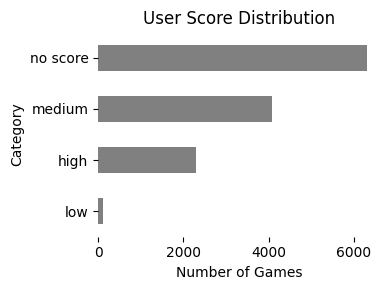

In [699]:
# User score categories distribution (horizontal bar chart)
ax = games_actual['user_score_category'].value_counts().sort_values().plot(
    kind='barh',
    color='gray',
    figsize=(4,3)
)

ax.set_title('User Score Distribution')
ax.set_xlabel('Number of Games')
ax.set_ylabel('Category')

# Remove plot frame (spines) for cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [691]:
# Count critic score categories
critic_counts = (
    games_actual['critic_score_category']
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'critic_score_category'})
)

critic_counts

,critic_score_category,count
0,no score,5612
1,medium,5422
2,high,1692
3,low,55


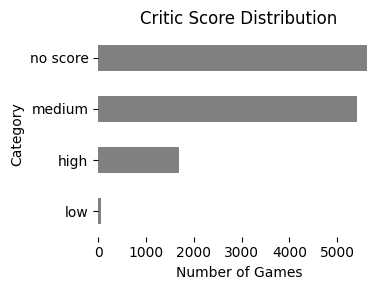

In [698]:
# Critic score categories distribution (horizontal bar chart)
ax = games_actual['critic_score_category'].value_counts().sort_values().plot(
    kind='barh',
    color='gray',
    figsize=(4,3)
)

ax.set_title('Critic Score Distribution')
ax.set_xlabel('Number of Games')
ax.set_ylabel('Category')

# Remove plot frame (spines) for cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## Top platforms

In [693]:
# Top platforms by number of games
top_platforms = (
    games_actual['platform']
    .value_counts()
    .head(7)
    .reset_index(name='games_count')
    .rename(columns={'index': 'platform'})
)

top_platforms

,platform,games_count
0,PS2,2127
1,DS,2120
2,Wii,1275
3,PSP,1180
4,X360,1121
5,PS3,1087
6,GBA,811


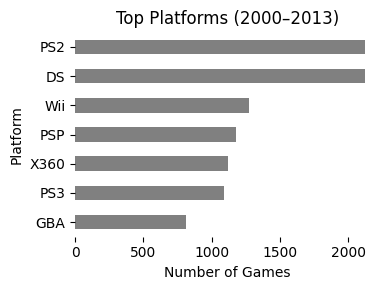

In [697]:
# Platform distribution (horizontal bar chart)
ax = games_actual['platform'].value_counts().head(7).sort_values().plot(
    kind='barh',
    color='gray',
    figsize=(4,3)
)

ax.set_title('Top Platforms (2000–2013)')
ax.set_xlabel('Number of Games')
ax.set_ylabel('Platform')

# Remove plot frame (spines) for cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## Final conclusion

In this project, a full data preprocessing and exploratory analysis pipeline was performed.

The dataset was cleaned by handling missing values, normalizing categorical variables, and removing duplicates. As a result, 235 duplicate rows were removed, and the dataset size decreased from 16956 to 16444 rows (about 3.02%).

A filtered dataset for the period 2000–2013 was created for more focused analysis.

New features were introduced by categorizing user and critic scores into qualitative groups (high, medium, low, no score). These transformations allowed for clearer interpretation of rating distributions.

Finally, the most popular gaming platforms were identified, with PS2, DS, and Wii leading in terms of number of released games.

Overall, the dataset is now clean, structured, and ready for further analytical insights.

## Analysis

### Sales over time

In [640]:
# Sales by year (table)
sales_by_year = games_actual.groupby('year_of_release')[['na_sales','eu_sales','jp_sales']].sum().round(2)
sales_by_year

,na_sales,eu_sales,jp_sales
year_of_release,,,
2000,94.50,52.77,42.77
2001,173.98,94.89,39.86
2002,216.19,109.75,41.76
2003,193.61,103.81,34.20
2004,222.51,106.19,41.65
2005,242.15,121.11,54.27
2006,262.13,127.36,73.74
2007,309.89,157.29,60.36
2008,348.69,180.70,60.24


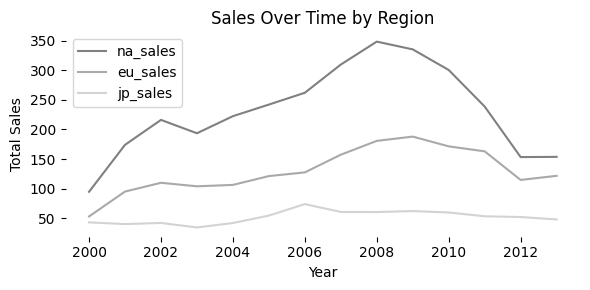

In [641]:
# Visualization of sales over time
ax = sales_by_year.plot(
    figsize=(6,3),
    color=['gray','darkgray','lightgray']
)

ax.set_title('Sales Over Time by Region')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales')

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**Insight**

North America shows the highest sales across most years.
Europe follows a similar trend but with lower values, while Japan remains the smallest market among the three regions.

### Top Genres

In [642]:
# Count number of games per genre and select top 7 most popular genres
top_genres = games_actual['genre'].value_counts().head(7)
top_genres

genre
action          2460
sports          1818
misc            1484
role-playing    1079
adventure       1009
shooter         1001
racing           966
Name: count, dtype: int64

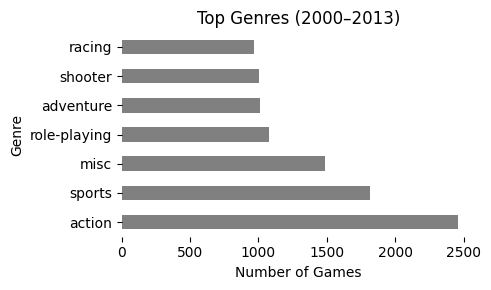

In [643]:
# Horizontal bar chart showing top 7 most popular genres (2000–2013)
ax = top_genres.plot(
    kind='barh',
    figsize=(5,3),
    color='gray'
)

ax.set_title('Top Genres (2000–2013)')
ax.set_xlabel('Number of Games')
ax.set_ylabel('Genre')

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**Insight**

- Action is the most popular genre by number of games, followed by Sports.
- This suggests that fast-paced and competitive games dominated the market during 2000–2013.
- Other genres are relatively balanced, with no extreme dominance after the top two categories.

### Total sales by genre across regions

In [644]:
# Total sales by genre across regions (North America, Europe, Japan)
# Values are summed and rounded for readability
genre_region = games_actual.groupby('genre')[['na_sales','eu_sales','jp_sales']].sum().round(2)
genre_region

,na_sales,eu_sales,jp_sales
genre,,,
action,679.74,390.17,102.64
adventure,76.49,43.01,33.74
fighting,148.34,67.82,38.53
misc,350.22,183.41,79.89
platform,250.76,132.78,52.58
puzzle,63.50,39.23,23.25
racing,263.57,177.89,25.98
role-playing,248.83,127.52,210.55
shooter,416.21,228.50,18.41


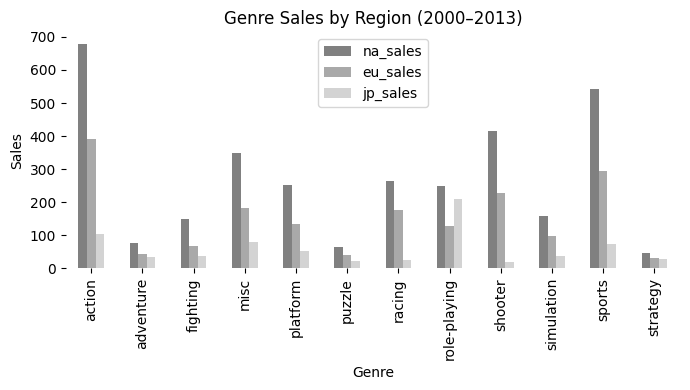

In [645]:
# Bar chart showing total sales by genre across regions (NA, EU, JP)
# This helps compare regional preferences for different game genres
ax = genre_region.plot(
    kind='bar',
    figsize=(7,4),
    color=['gray','darkgray','lightgray']
)

ax.set_title('Genre Sales by Region (2000–2013)')
ax.set_xlabel('Genre')
ax.set_ylabel('Sales')

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**Insight**

- North America and Europe show similar genre preferences, with Action and Sports dominating both markets.
- In contrast, Japan demonstrates a different pattern, where Role-Playing games are the most popular genre by sales.
- This highlights clear regional differences in gaming preferences.

### User Score vs Sales

In [646]:
# User score vs sales (all available data)
user_score_sales = games_actual[['user_score', 'eu_sales', 'jp_sales', 'na_sales']].dropna()
user_score_sales

,user_score,eu_sales,jp_sales,na_sales
0,8.0,28.96,3.77,41.36
2,8.3,12.76,3.79,15.68
3,8.0,10.93,3.28,15.61
6,8.5,9.14,6.50,11.28
7,6.6,9.18,2.93,13.96
...,...,...,...,...
16902,2.4,0.00,0.00,0.01
16913,8.8,0.00,0.00,0.01
16936,5.8,0.00,0.00,0.01
16943,7.2,0.01,0.00,0.00


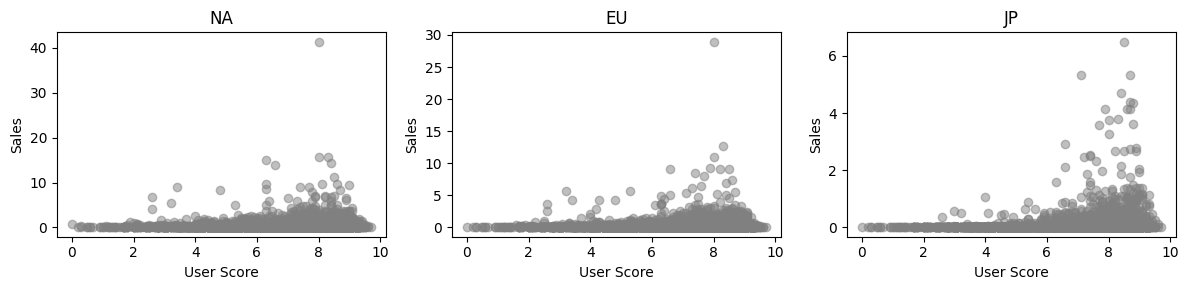

In [647]:
# Create a 1x3 subplot layout to visualize relationship between user score and sales across regions
fig, axes = plt.subplots(1, 3, figsize=(12,3))

# NA
axes[0].scatter(user_score_sales['user_score'], user_score_sales['na_sales'], color='gray', alpha=0.5)
axes[0].set_title('NA')

# EU
axes[1].scatter(user_score_sales['user_score'], user_score_sales['eu_sales'], color='gray', alpha=0.5)
axes[1].set_title('EU')

# JP
axes[2].scatter(user_score_sales['user_score'], user_score_sales['jp_sales'], color='gray', alpha=0.5)
axes[2].set_title('JP')

for ax in axes:
    ax.set_xlabel('User Score')
    ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()

###  Critic Score vs Sales

In [648]:
# Critic score vs sales (all available data)
critic_score_sales = games_actual[['critic_score', 'na_sales', 'eu_sales', 'jp_sales']].dropna()
critic_score_sales

,critic_score,na_sales,eu_sales,jp_sales
0,76.0,41.36,28.96,3.77
2,82.0,15.68,12.76,3.79
3,80.0,15.61,10.93,3.28
6,89.0,11.28,9.14,6.50
7,58.0,13.96,9.18,2.93
...,...,...,...,...
16936,61.0,0.01,0.00,0.00
16937,53.0,0.01,0.00,0.00
16938,48.0,0.01,0.00,0.00
16943,60.0,0.00,0.01,0.00


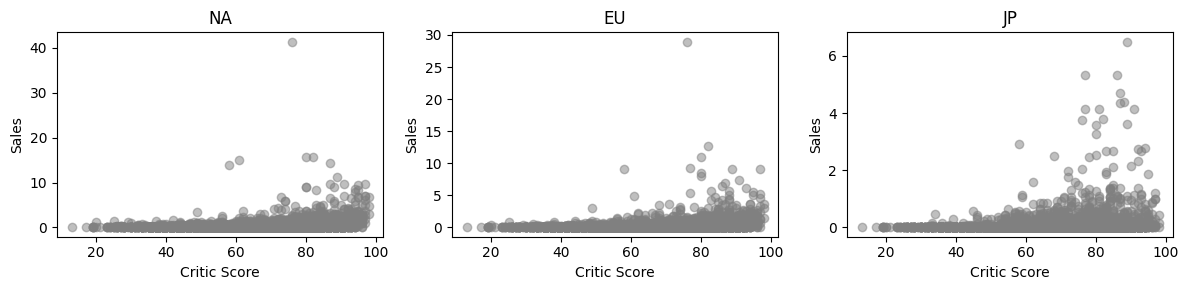

In [649]:
# Create a 1x3 subplot layout to visualize relationship between critic score and sales across regions
fig, axes = plt.subplots(1, 3, figsize=(12,3))

# NA
axes[0].scatter(critic_score_sales['critic_score'], critic_score_sales['na_sales'], color='gray', alpha=0.5)
axes[0].set_title('NA')

# EU
axes[1].scatter(critic_score_sales['critic_score'], critic_score_sales['eu_sales'], color='gray', alpha=0.5)
axes[1].set_title('EU')

# JP
axes[2].scatter(critic_score_sales['critic_score'], critic_score_sales['jp_sales'], color='gray', alpha=0.5)
axes[2].set_title('JP')

for ax in axes:
    ax.set_xlabel('Critic Score')
    ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()

### Correlation between score and sales

In [650]:
# Correlation between critic score and sales (all regions)
games_actual[['critic_score','na_sales','eu_sales','jp_sales']].corr()

,critic_score,na_sales,eu_sales,jp_sales
critic_score,1.000000,0.234600,0.209660,0.141917
na_sales,0.234600,1.000000,0.852090,0.429293
eu_sales,0.209660,0.852090,1.000000,0.478155
jp_sales,0.141917,0.429293,0.478155,1.000000


In [651]:
# Correlation between user score and sales (all regions)
games_actual[['user_score','na_sales','eu_sales','jp_sales']].corr()

,user_score,na_sales,eu_sales,jp_sales
user_score,1.000000,0.082885,0.062023,0.111996
na_sales,0.082885,1.000000,0.852090,0.429293
eu_sales,0.062023,0.852090,1.000000,0.478155
jp_sales,0.111996,0.429293,0.478155,1.000000


**Insight**

- Critic scores show a weak positive correlation with sales across all regions (≈0.14–0.23), slightly stronger than user scores.
- User scores demonstrate almost no relationship with sales, indicating that user ratings have minimal impact on commercial performance.
- North America shows the strongest relationship between ratings and sales, while Japan shows the weakest.
- Overall, ratings are not a strong predictor of game sales.

## Final Conclusion

The analysis of the video game industry from 2000 to 2013 reveals several key patterns.

The North American market was the largest across all years, followed by Europe, while Japan represented a smaller but structurally different market.

In terms of genres, Action and Sports games dominated in North America and Europe, while Role-Playing games were the most popular in Japan, showing clear regional differences in user preferences.

Platform analysis shows that a small number of platforms account for the majority of game releases, indicating a concentrated market structure.

Sales peaked around 2007–2008 and then gradually declined, which may reflect market saturation and the transition to new gaming generations.

Finally, the relationship between game ratings and sales is weak. Critic scores show a slightly stronger correlation with sales than user scores, but neither is a strong predictor of commercial success.

Overall, game sales are primarily driven by platform popularity, genre preferences, and regional market differences rather than review scores alone.